Shape: (1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  O

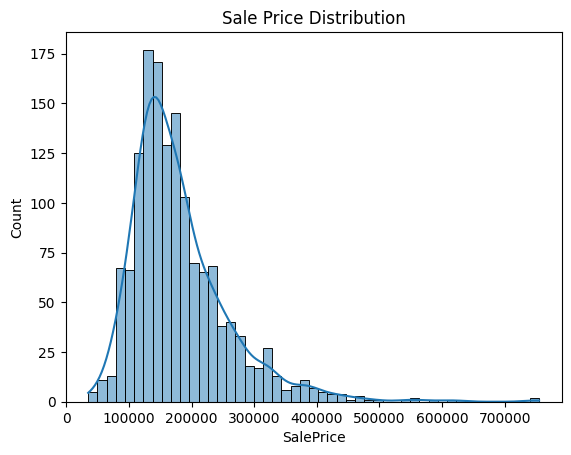

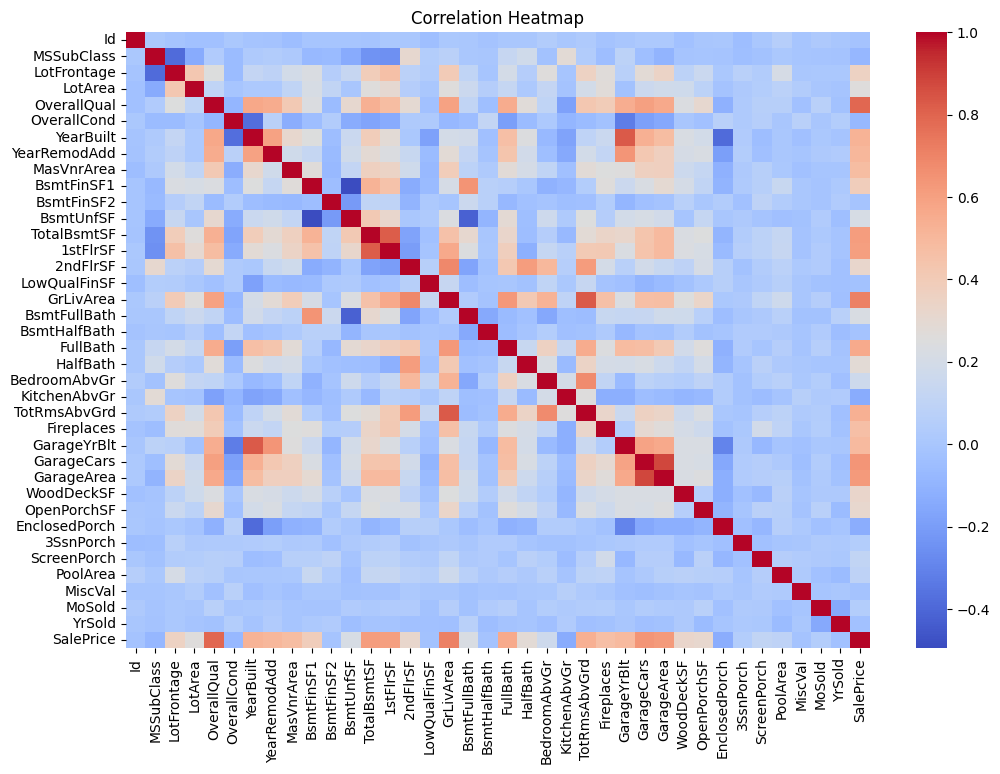

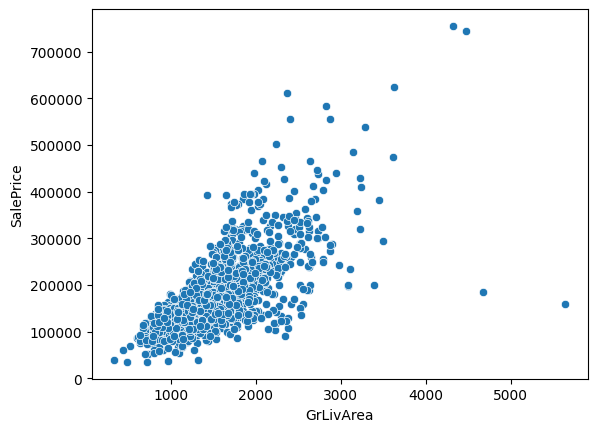

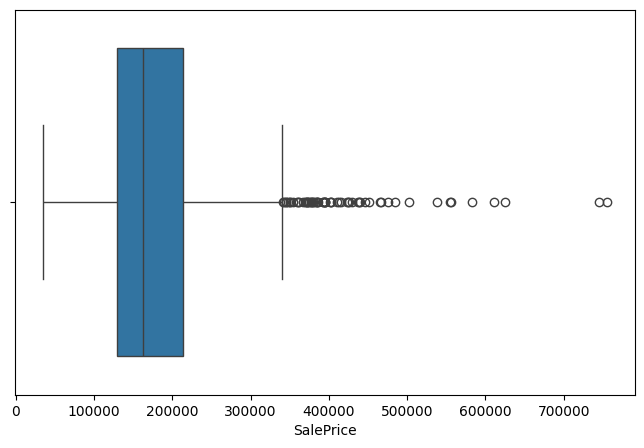

PoolQC          1451
MiscFeature     1402
Alley           1365
Fence           1176
MasVnrType       871
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


C:\Users\sures\AppData\Local\Temp\ipykernel_16608\3280450349.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object"]).columns


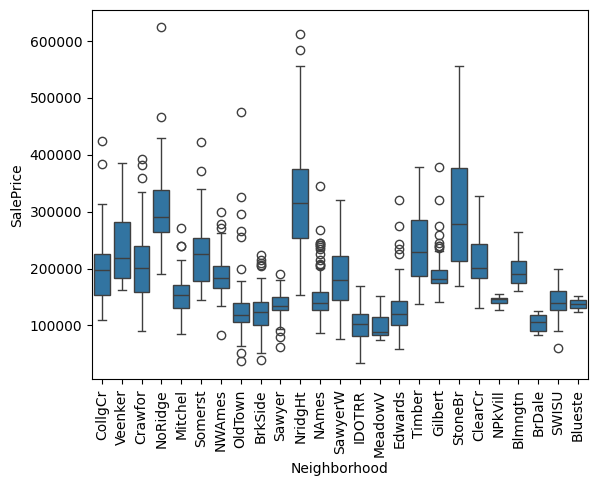

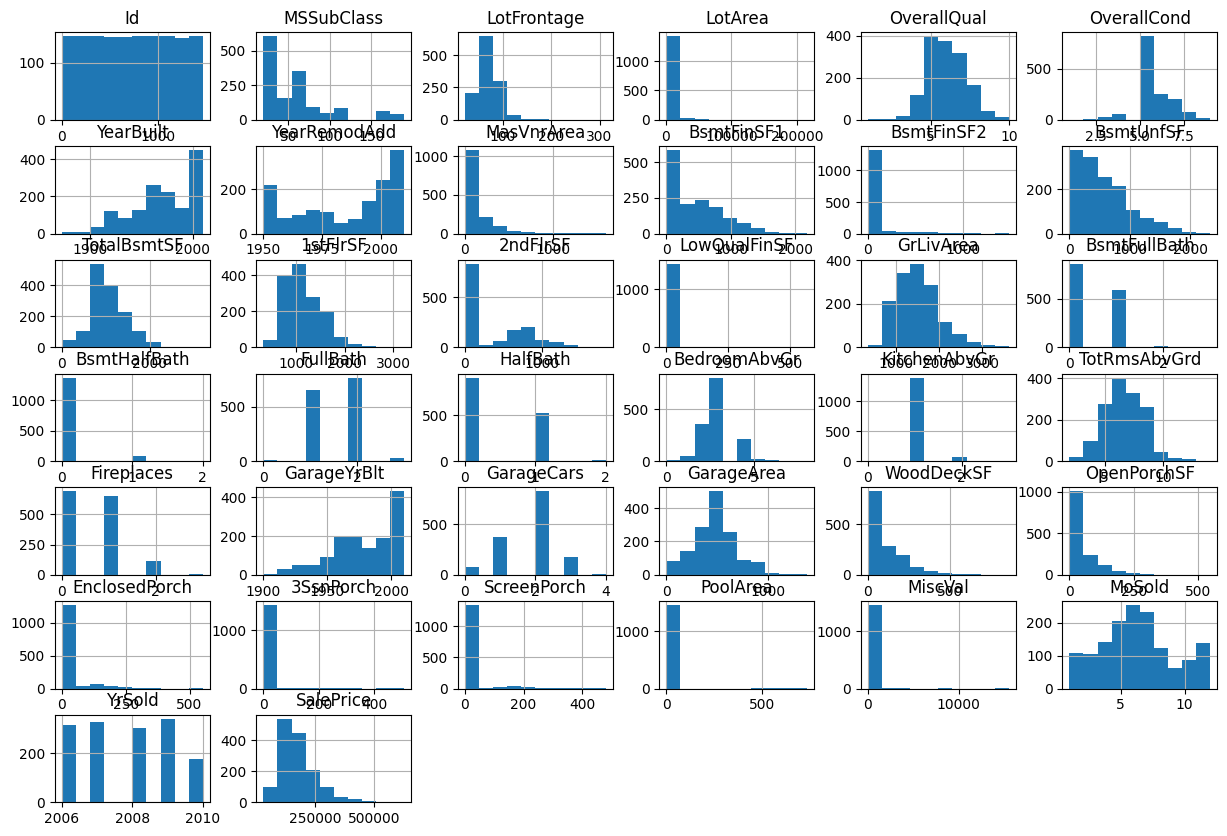

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/raw/train.csv")

# Basic info
print("Shape:", df.shape)
df.head()
df.info()
sns.histplot(df["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
corr["SalePrice"].sort_values(ascending=False).head(10)
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=df["SalePrice"])
plt.show()
df = df[df["GrLivArea"] < 4000]
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(20))
df.select_dtypes(include=["object"]).columns
sns.boxplot(x="Neighborhood", y="SalePrice", data=df)
plt.xticks(rotation=90)
plt.show()
df.hist(figsize=(15,10))
plt.show()
df.to_csv("../data/cleaned_data.csv", index=False)